In [1]:
import mysql.connector
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px 
import seaborn as sns
import os
from dotenv import load_dotenv

load_dotenv(override=True)


True

In [2]:
#extraer los datos de mySQL y crear un DataFrame de pandas
def extract_data_from_mysql(query):
    """
    Extrae los datos de una consulta SQL y los devuelve en un DataFrame.

    Parámetros:
    query (str): Consulta SQL que se ejecutará sobre la base de datos.

    Retorna:
    pd.DataFrame: DataFrame con los resultados obtenidos de la consulta.
    """

    # Configuración de la conexión a la base de datos
    config = {
          'user':     os.getenv('MYSQL_USER'),
          'password': os.getenv('MYSQL_PASSWORD'),
          'host':     os.getenv('MYSQL_HOST'),
          'database': os.getenv('MYSQL_DATABASE'),
      }

    # Establecer la conexión
    conn = mysql.connector.connect(**config)

    # Crear DataFrame
    df_emisiones = pd.read_sql(query, conn)

    # Cerrar la conexión
    conn.close()
    return df_emisiones
  



C:\Users\UsuarioM.XTALENTO104\AppData\Local\Temp\ipykernel_26596\1320954750.py:25: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_emisiones = pd.read_sql(query, conn)


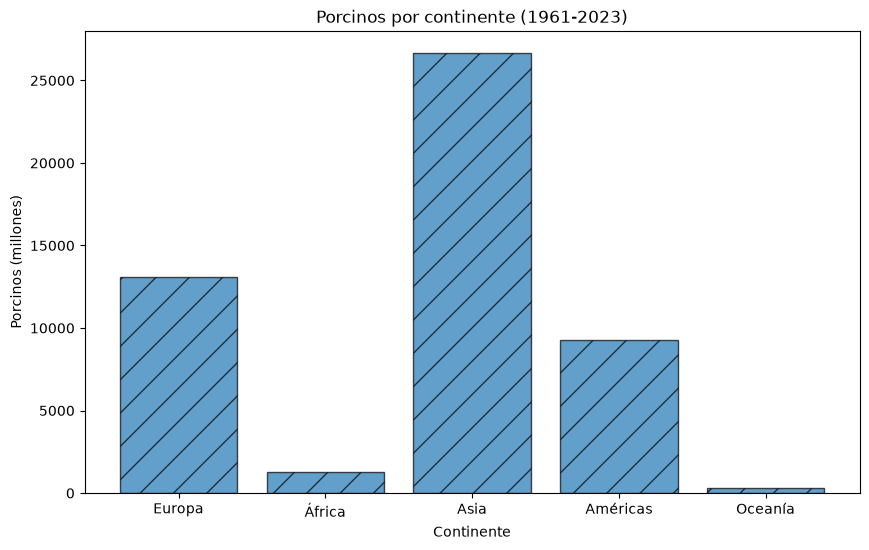

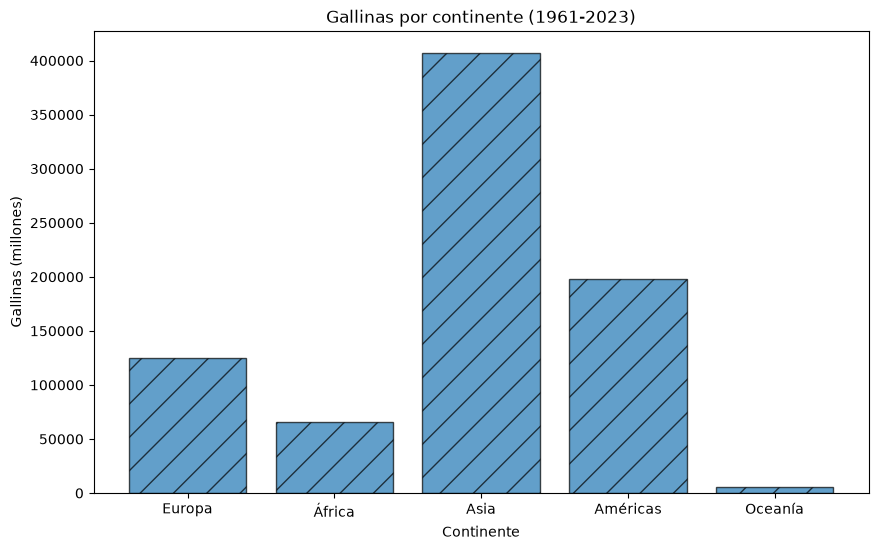

In [3]:
## gráfico de barras para medir especies por continente

def matplotlib_especie_continente(df, especie):
    value = df['valor'].values / 1000000
    plt.figure(figsize=(10,6))
    plt.title(f'{especie} por continente (1961-2023)')
    plt.bar(df['area'], value, alpha=0.7, edgecolor='black', hatch='/')
    plt.xlabel('Continente')
    plt.ylabel(f'{especie} (millones)')
    plt.show()


# df porcinos
df_porcinos=extract_data_from_mysql("""SELECT area, sum(valor) as valor FROM proyecto_final.dataset_fao where (producto = 'Porcinos de carne' or producto = 'Porcinos de cría') and elemento = 'Existencias' group by area""") 

matplotlib_especie_continente(df_porcinos, 'Porcinos')

#df gallinas
df_gallinas= extract_data_from_mysql("""SELECT area, sum(valor) as valor FROM proyecto_final.dataset_fao where (producto = 'Gallinas, parrilleros' or producto = 'Gallinas, ponedoras') and elemento = 'Existencias' group by area""") #df con gallinas

matplotlib_especie_continente(df_gallinas, 'Gallinas')


#print(df_porcinos.head())


C:\Users\UsuarioM.XTALENTO104\AppData\Local\Temp\ipykernel_26596\1320954750.py:25: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_emisiones = pd.read_sql(query, conn)


   anio         valor
0  1961  9.421221e+08
1  1962  9.571212e+08
2  1963  9.703314e+08
3  1964  9.875251e+08
4  1965  1.008857e+09


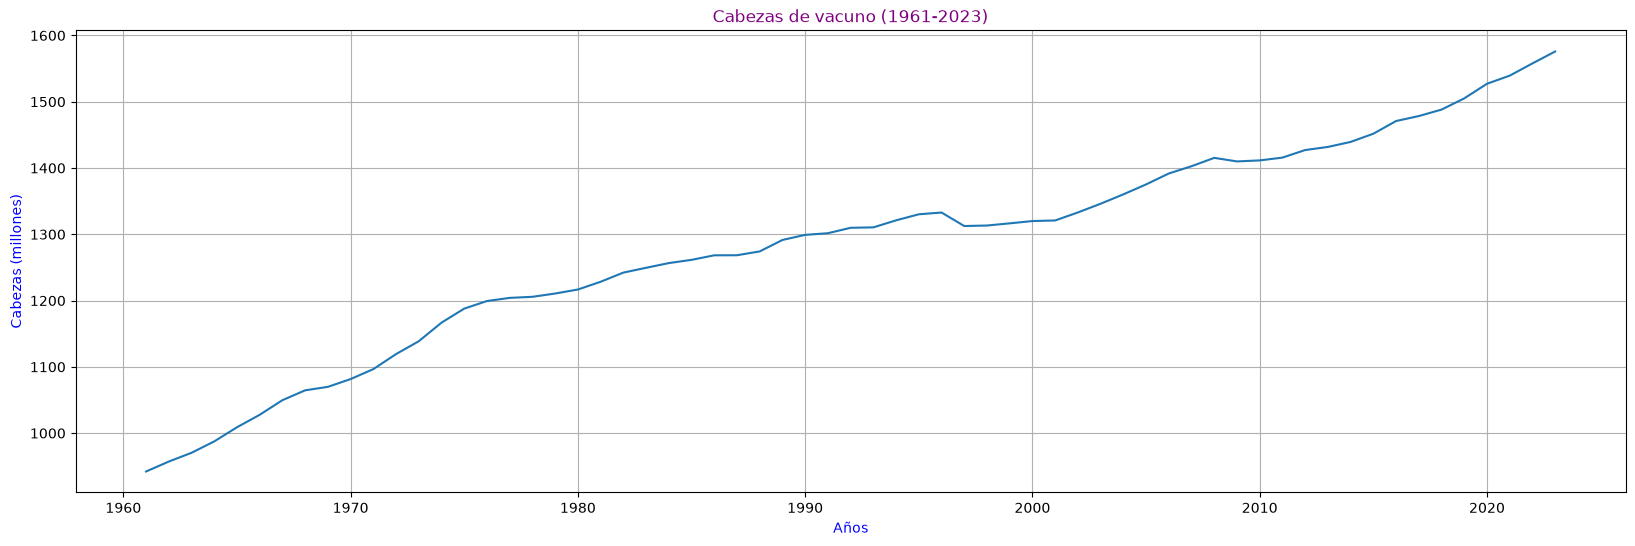

In [4]:
## Gráfico de líneas

#df con vacunos
df_vacunos = extract_data_from_mysql("""select anio, sum(valor) as valor from proyecto_final.dataset_fao where (producto = 'Vacas lecheras' or producto = 'Vacunos, otros') and elemento = 'Existencias' group by anio""")

print(df_vacunos.head())

def linePlot(df): 
    value = df['valor'].values / 1000000 #dividir entre un millón porque son datos muy grandes, para ajustar la escala
    plt.figure(figsize= (20,6))
    plt.plot(df['anio'],  value) 
    plt.xlabel('Años', color = 'blue' )
    plt.ylabel('Cabezas (millones)', color = 'blue')
    plt.grid()#marca la cuadrícula por debajo 
    plt.title('Cabezas de vacuno (1961-2023)', color = 'purple')
    plt.show()

linePlot(df_vacunos)


In [5]:
# Gráfico interactivo con Plotly Express para número de animales por continente en el año 2023

#dataframe con el número de animales para cada continente

df_especies_continente = extract_data_from_mysql(""" 
       SELECT
        area,
        SUM(CASE WHEN codigo_producto = 'F1053' or codigo_producto = 'F1052' THEN valor ELSE 0 END) AS Gallinas,
        SUM(CASE WHEN codigo_producto ='F0960' THEN valor ELSE 0 END) AS Vacunos
    FROM proyecto_final.dataset_fao
    WHERE codigo_producto IN ('F1053','F1052','F0960')
    and anio = 2023
    and elemento = 'Existencias'
    GROUP BY area
    ORDER BY area""")

fig = px.bar(
    df_especies_continente,
    x='area',
    y='Vacunos',
    hover_data = ['Gallinas'], #el dato de N2O aparece al pasar el ratón por encima
    title='Número de animales(vacunos/gallinas) por continente en 2023',
    color = 'area' #un color para cada continente   
)    

fig.show() #muestra el gráfico interactivo en el notebook

## EXPORTACIÓN A HTML
fig.write_html('interactivo_animales_2023.html')#genera un fichero interactivo.html que se puede abrir con el explorador de archivos


C:\Users\UsuarioM.XTALENTO104\AppData\Local\Temp\ipykernel_26596\1320954750.py:25: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_emisiones = pd.read_sql(query, conn)


C:\Users\UsuarioM.XTALENTO104\AppData\Local\Temp\ipykernel_26596\1320954750.py:25: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_emisiones = pd.read_sql(query, conn)


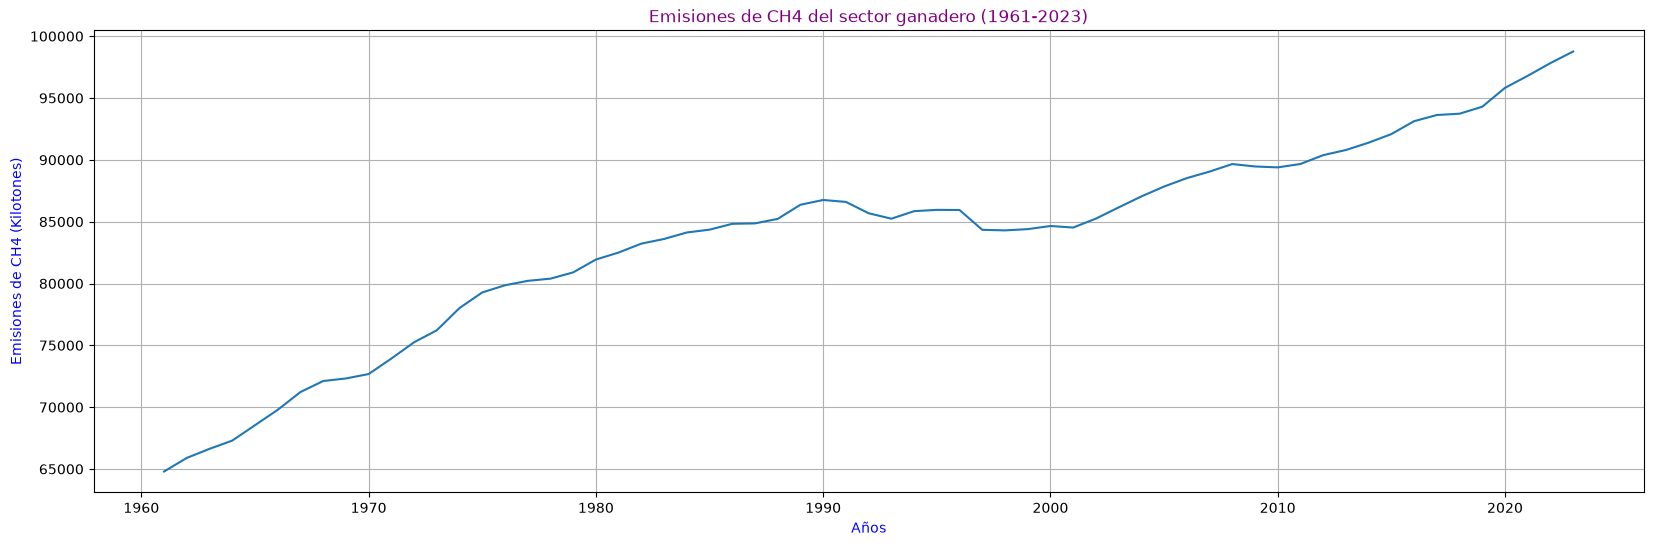

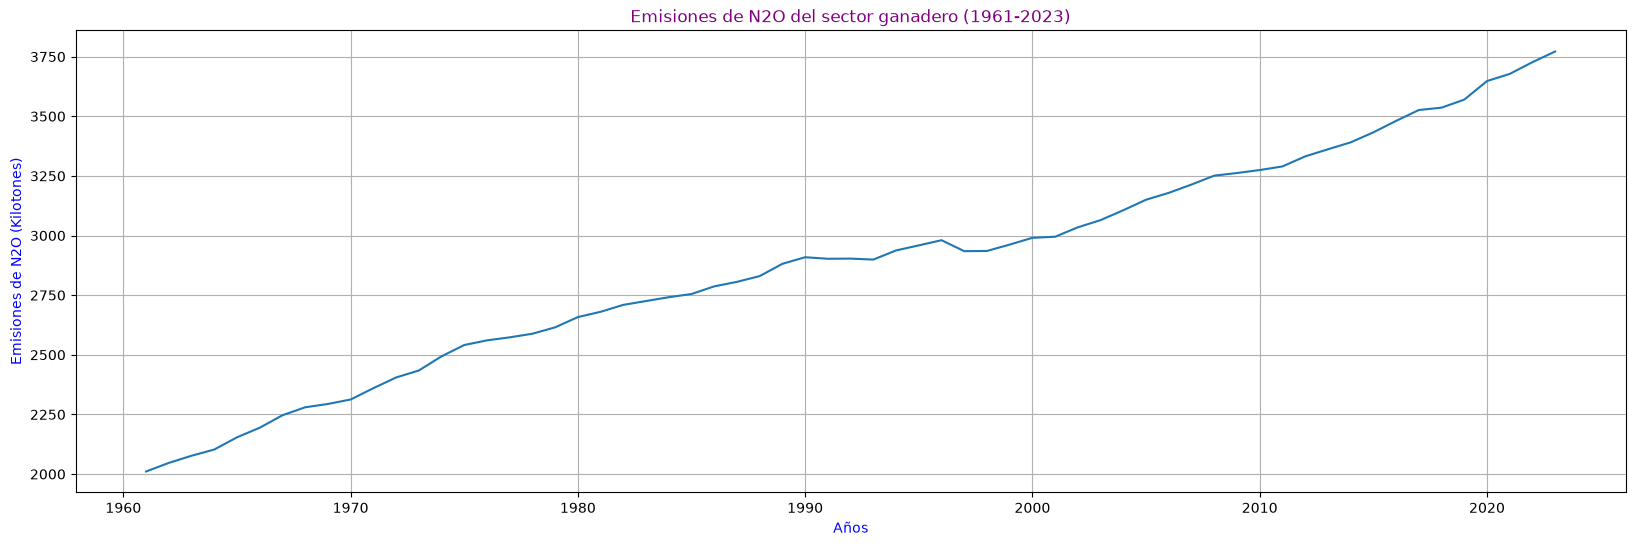

In [6]:
# Emisiones de CH4 total del sector ganadero por año

df_CH4 = extract_data_from_mysql("""select anio, sum(valor) as valor from proyecto_final.dataset_fao where codigo_elemento = 72441 group by anio""") #df con emisiones de CH4


def linePlot_emisiones(df): 
    plt.figure(figsize= (20,6))#tamaño del lienzo en pulgadas (ancho x alto)
    plt.plot(df['anio'],  df['valor']) 
    plt.xlabel('Años', color = 'blue' )
    plt.ylabel('Emisiones de CH4 (Kilotones)', color = 'blue')
    plt.grid()#marca la cuadrícula por debajo 
    plt.title('Emisiones de CH4 del sector ganadero (1961-2023)', color = 'purple')
    plt.show()

linePlot_emisiones(df_CH4)


# Emisiones de N2O total del sector ganadero por año

df_N2O = extract_data_from_mysql("""select anio, sum(valor) as valor from proyecto_final.dataset_fao where codigo_elemento = 72431 group by anio""") #df con emisiones de N2O

def linePlot_emisiones_N2O(df):
    plt.figure(figsize= (20,6))#tamaño del lienzo en pulgadas (ancho x alto)
    plt.plot(df['anio'],  df['valor']) 
    plt.xlabel('Años', color = 'blue' )
    plt.ylabel('Emisiones de N2O (Kilotones)', color = 'blue')
    plt.grid()#marca la cuadrícula por debajo 
    plt.title('Emisiones de N2O del sector ganadero (1961-2023)', color = 'purple')
    plt.show()

linePlot_emisiones_N2O(df_N2O)







       area           CH4         N2O
0    África  6.459890e+05  33726.4766
1  Américas  1.806710e+06  54275.6885
2      Asia  1.369993e+06  49839.8608
3    Europa  1.201589e+06  33360.2996
4   Oceanía  2.469904e+05  10248.9072


C:\Users\UsuarioM.XTALENTO104\AppData\Local\Temp\ipykernel_26596\1320954750.py:25: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_emisiones = pd.read_sql(query, conn)


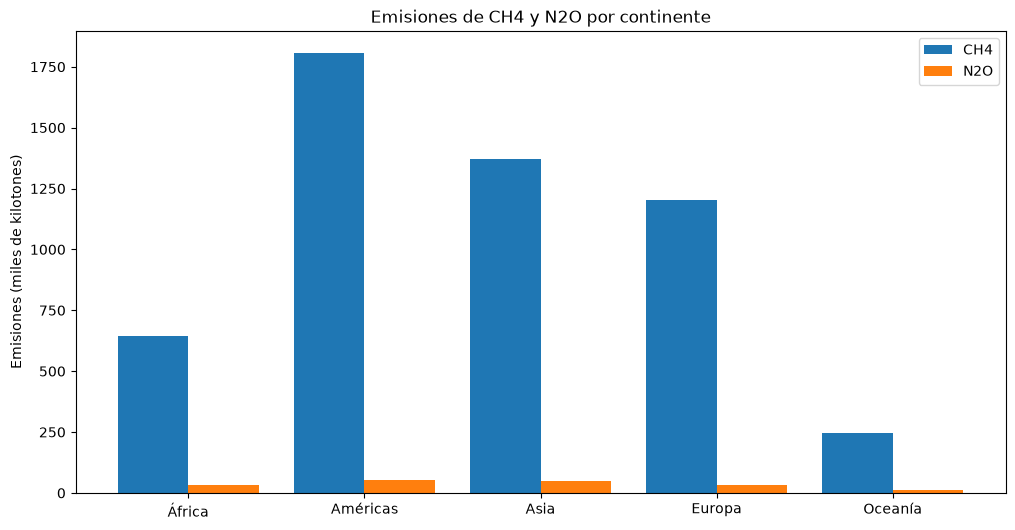

In [7]:
# Gráfico de barras: emisiones CH4 y N2O por continente
# Agrupamos los valores totales de cada gas por área (continente)

df_emisiones_continente = extract_data_from_mysql("""SELECT
        area,
        SUM(CASE WHEN codigo_elemento = 72441 THEN valor ELSE 0 END) AS CH4,
        SUM(CASE WHEN codigo_elemento = 72431 THEN valor ELSE 0 END) AS N2O
    FROM proyecto_final.dataset_fao
    WHERE codigo_elemento IN (72441, 72431)
    GROUP BY area
    ORDER BY area
""")

print(df_emisiones_continente.head())





continentes = df_emisiones_continente['area']
x = np.arange(len(continentes)) #array [0,1,2,3,4] para saber el nº de continentes 
width = 0.40 #ancho de columna, lo divide entre 2 para que la 1ª mitad sea CH4 y la segunda N2O

plt.figure(figsize=(12, 6))
plt.bar(x - width/2, df_emisiones_continente['CH4'] / 1000, width=width, label='CH4', color='tab:blue')
plt.bar(x + width/2, df_emisiones_continente['N2O'] / 1000, width=width, label='N2O', color='tab:orange')

plt.xticks(x, continentes)
plt.ylabel('Emisiones (miles de kilotones)')
plt.title('Emisiones de CH4 y N2O por continente')
plt.legend()
plt.show()



In [8]:


# Gráfico interactivo con Plotly Express 

fig = px.bar(
    df_emisiones_continente,
    x='area',
    y='N2O',
    hover_data = ['CH4'], #el dato de N2O aparece al pasar el ratón por encima
    title='Emisiones de N2O por continente',
    color = 'area' #un color para cada continente   
)    

fig.show() #muestra el gráfico interactivo en el notebook

## EXPORTACIÓN A HTML
fig.write_html('interactivo_emisiones.html')#genera un fichero interactivo.html que se puede abrir con el explorador de archivos

C:\Users\UsuarioM.XTALENTO104\AppData\Local\Temp\ipykernel_26596\1320954750.py:25: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_emisiones = pd.read_sql(query, conn)


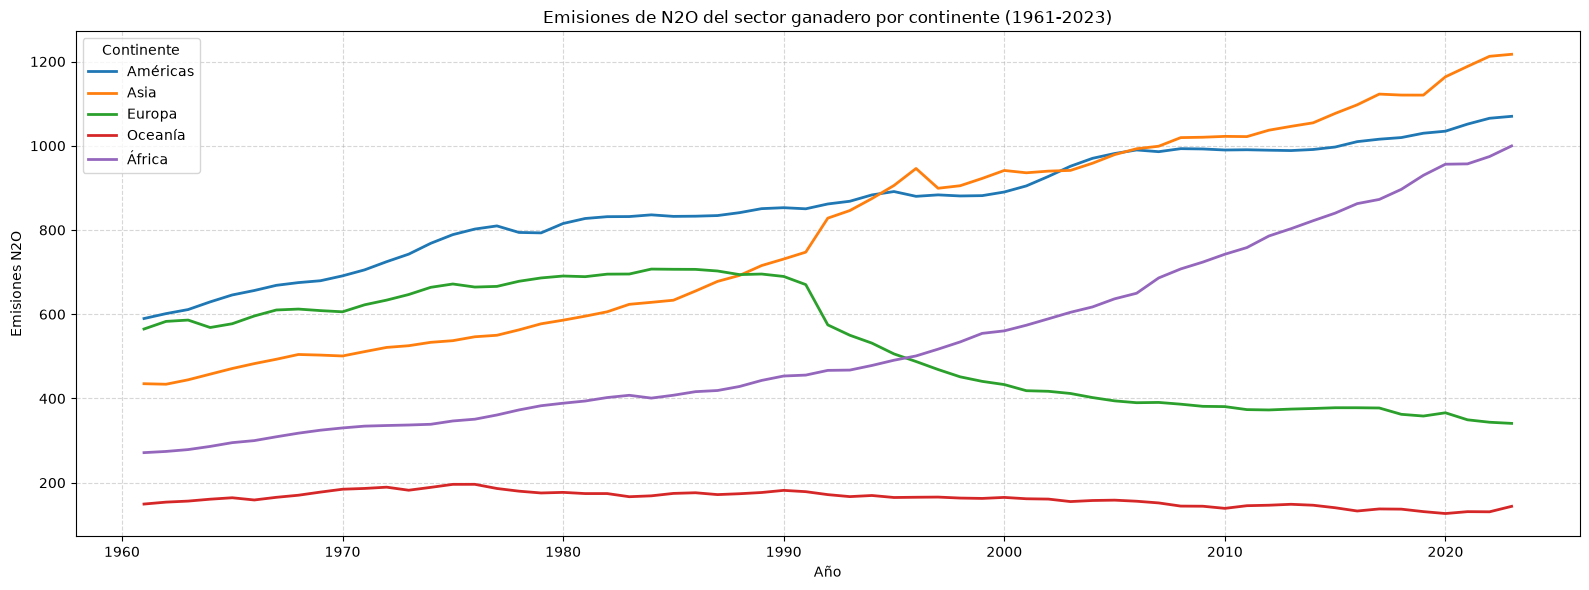

In [9]:
df_n2o_continente = extract_data_from_mysql("""
    SELECT
        anio,
        area,
        SUM(valor) AS valor_n2o
    FROM proyecto_final.dataset_fao
    WHERE codigo_elemento = 72431
    GROUP BY anio, area
    ORDER BY anio, area
""")


def plot_n2o_by_continent(df, figsize=(16, 6)):
    plt.figure(figsize=figsize)
    for continente, grupo in df.groupby('area'):
        plt.plot(
            grupo['anio'],
            grupo['valor_n2o'],
            linewidth=2,
            label=continente
        )

    plt.xlabel('Año')
    plt.ylabel('Emisiones N2O')
    plt.title('Emisiones de N2O del sector ganadero por continente (1961-2023)')
    plt.legend(title='Continente')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


plot_n2o_by_continent(df_n2o_continente)


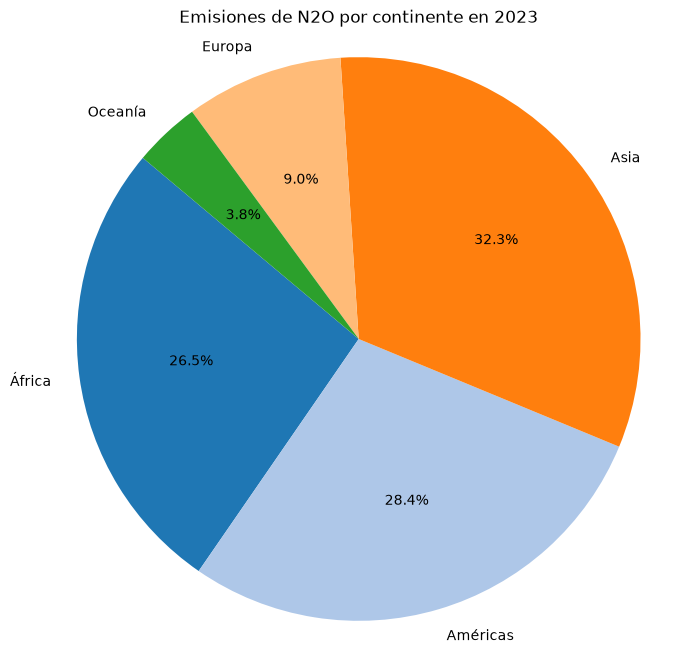

In [10]:
# gráfico de tarta de las fuentes de emisiones de N2O por continente en el último año disponible (2023)

def plot_pie_n2o_last_year(df, year=2023):
    df_last_year = df[df['anio'] == year]
    plt.figure(figsize=(8, 8))
    plt.pie(
        df_last_year['valor_n2o'],
        labels=df_last_year['area'],
        autopct='%1.1f%%',
        startangle=140,
        colors=plt.cm.tab20.colors
    )
    plt.title(f'Emisiones de N2O por continente en {year}')
    plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
    plt.show()

plot_pie_n2o_last_year(df_n2o_continente, year=2023)

C:\Users\UsuarioM.XTALENTO104\AppData\Local\Temp\ipykernel_26596\1320954750.py:25: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_emisiones = pd.read_sql(query, conn)


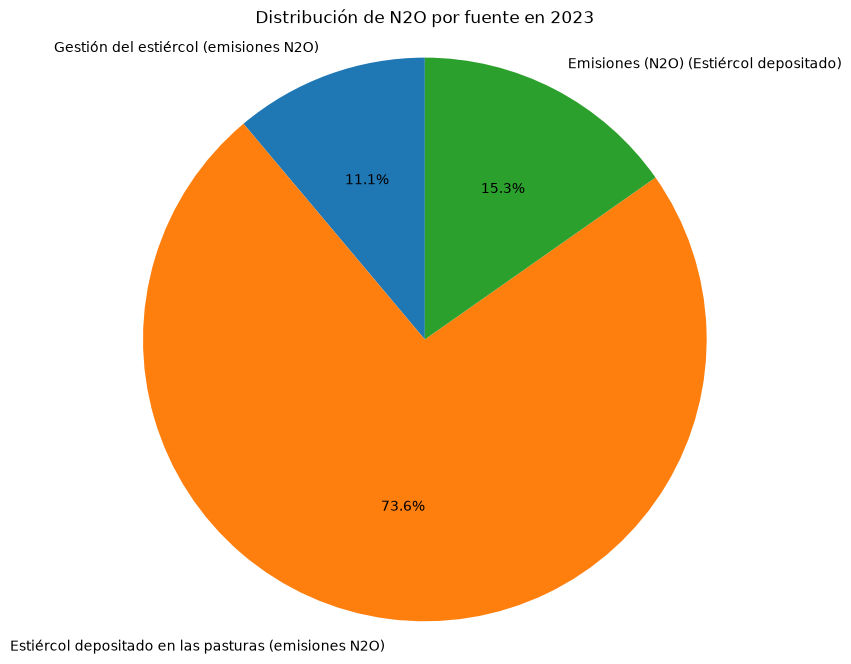

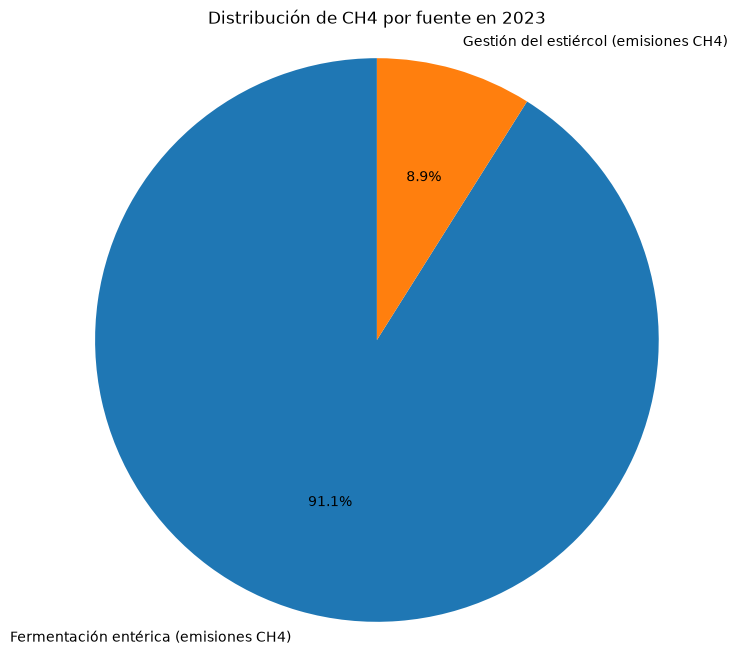

In [11]:
#gráfico de tarta de las fuentes de N2O en 2023

#df con emisiones de N2O por continente en 2023
df_fuentes_n2o = extract_data_from_mysql("""select elemento, sum(valor) as valor  from proyecto_final.dataset_fao where codigo_elemento in (72306, 72300, 72301) and anio = 2023 group by elemento""") #df con emisiones de N2O por fuente en 2023


def plot_pie(df, labels_col='producto', values_col='valor', title='Distribución de N2O en 2023'):
    plt.figure(figsize=(8, 8))
    plt.pie(
        df[values_col],
        labels=df[labels_col],
        autopct='%1.1f%%',
        startangle=90
    )
    plt.title(title)
    plt.axis('equal')
    plt.show()

plot_pie(df_fuentes_n2o, labels_col='elemento', values_col='valor', title='Distribución de N2O por fuente en 2023')


#gráfico de tarta de las fuentes de CH4 en 2023

df_fuentes_ch4 = extract_data_from_mysql("""select elemento, sum(valor) as valor  from proyecto_final.dataset_fao where codigo_elemento in (72254,72256) and anio = 2023 group by elemento""")

plot_pie(df_fuentes_ch4, labels_col='elemento', values_col='valor', title='Distribución de CH4 por fuente en 2023')
